In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from checks import * 
from stats import *

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("data/result/final.csv")

In [3]:
check_data(data)

Размер данных: (1335, 31)
Типы столбцов year                 int64
hs2                  int64
exporter            object
importer            object
exporter_iso3       object
importer_iso3       object
partner             object
partner_iso3        object
direction           object
value              float64
quantity           float64
price              float64
net_export         float64
gdp_partner        float64
gdp_russia         float64
cpi_partner        float64
cpi_russia         float64
ex_rate_partner    float64
ex_rate_russia     float64
bilateral_er       float64
iip_partner        float64
iip_russia         float64
dist               float64
contig             float64
comlang_off        float64
unfriendly           int64
sanction             int64
eu_member            int64
eaes_member          int64
brics_member         int64
cis_member           int64
dtype: object
Пропуски                  missing_count  missing_pct
net_export                 717        53.71
iip_partner 

In [4]:
# удаление записей с quantity = 0 и value > 0, по сути мусор + преобразование типов
data = data[~((data["quantity"] == 0) & (data["value"] > 0))].copy()
data["contig"] = data["contig"].astype("Int64")
data["comlang_off"] = data["comlang_off"].astype("Int64")

In [5]:
# Проверка наблюдений и пропусков
problematic, partner_stats = check_obs(data)
problematic.head(50)

,total_obs,missing_macro,total_macro,missing_pct
partner,,,,
CuraÃ§ao,1,5,8,0.625000
Tokelau,1,5,8,0.625000
Timor-Leste,1,4,8,0.500000
Aruba,1,2,8,0.250000
Marshall Isds,1,2,8,0.250000
Benin,1,1,8,0.125000
Dominica,1,1,8,0.125000
Gabon,1,1,8,0.125000
Sudan,1,1,8,0.125000


In [6]:
# удаление партнеров, по которым меньше трех наблюдений или кол-во пропусков по эк. показателям больше 0.5
to_drop = partner_stats.query(
    "total_obs < 3 or missing_pct > 0.5"
).index.tolist()
clean_data = data[~data["partner"].isin(to_drop)].copy()
clean_data["partner"].nunique(), data["partner"].nunique()

(132, 166)

In [7]:
# Статистика
clean_data.describe()

,year,hs2,value,quantity,price,net_export,gdp_partner,gdp_russia,cpi_partner,cpi_russia,...,iip_russia,dist,contig,comlang_off,unfriendly,sanction,eu_member,eaes_member,brics_member,cis_member
count,1260.000000,1260.0,1260.000000,1260.000000,1260.000000,574.000000,1.251000e+03,1.260000e+03,1227.000000,1260.000000,...,1260.000000,1226.000000,1226.0,1226.0,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000
mean,2019.846825,9.0,7455.721236,2512.610404,9.139613,-9426.626723,9.254758e+11,1.778760e+12,7.111483,5.633305,...,118.476960,4967.156345,0.143556,0.022838,0.394444,0.329365,0.274603,0.041270,0.038095,0.082540
std,1.934478,0.0,23427.981785,9423.988097,40.024235,31295.982836,3.002356e+12,2.555132e+11,22.885909,3.347669,...,8.830781,3644.815156,0.350782,0.149449,0.488925,0.470169,0.446491,0.198993,0.191502,0.275294
min,2017.000000,9.0,0.001000,0.001000,0.206683,-241008.487000,1.043411e+09,1.493076e+12,-2.814698,2.878297,...,106.880000,686.965700,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018.000000,9.0,25.792500,4.992250,2.286709,-3262.520000,3.809902e+10,1.574199e+12,1.610768,3.381659,...,110.800000,2065.183000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2020.000000,9.0,309.534500,111.667000,4.507513,0.032000,1.584685e+11,1.693115e+12,3.275829,4.470367,...,116.200000,3450.924000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2021.000000,9.0,3284.521500,976.841250,8.050026,119.436500,5.064744e+11,1.829187e+12,6.757021,6.694459,...,124.630000,7486.303000,0.0,0.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,2023.000000,9.0,241761.181000,112891.223000,1050.000000,61377.412000,2.772071e+13,2.291612e+12,557.201817,13.750000,...,135.970000,16774.490000,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
# Непрерывные переменные
num_cols = [
    "value", "quantity", "price",
    "gdp_partner", "gdp_russia",
    "cpi_partner", "cpi_russia",
    "bilateral_er",
    "iip_partner", "iip_russia",
    "dist"
]

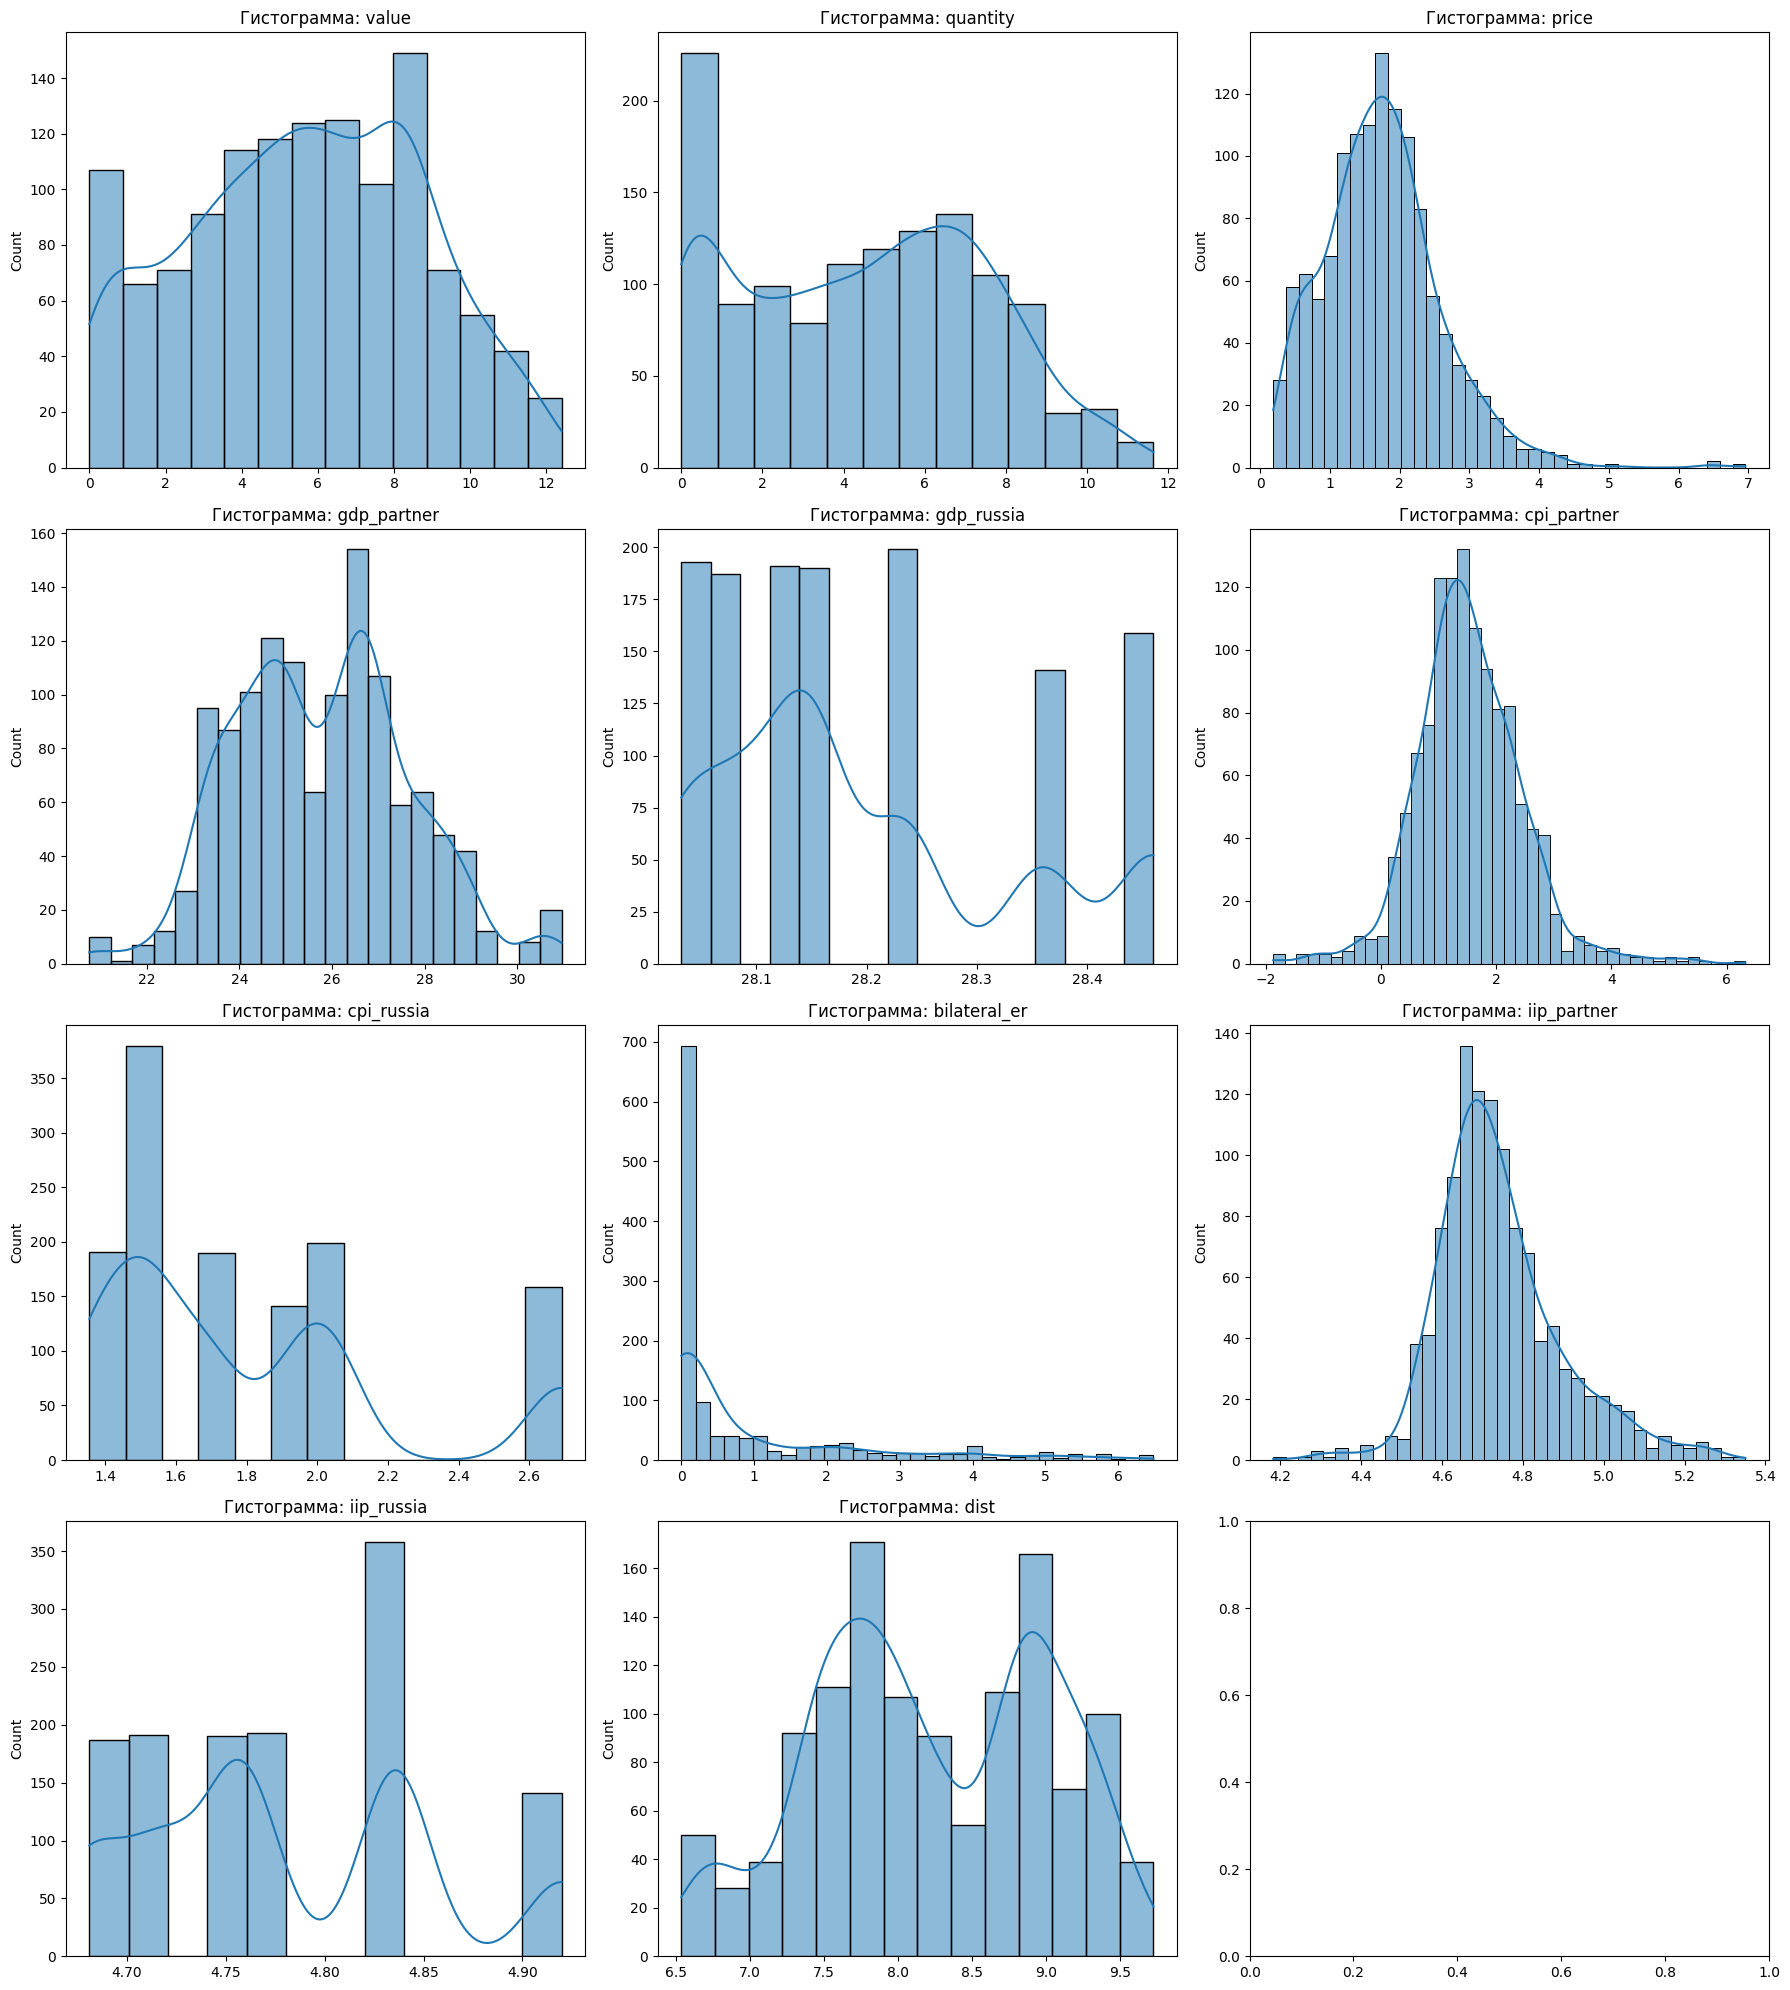

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()
# добавлен np.log1p для исправления масштаба
for i, col in enumerate(num_cols):
    sns.histplot(np.log1p(clean_data[col].dropna()), kde=True, ax=axes[i])
    axes[i].set_title(f"Гистограмма: {col}")
    axes[i].set_xlabel("")
    
plt.tight_layout()
plt.show()

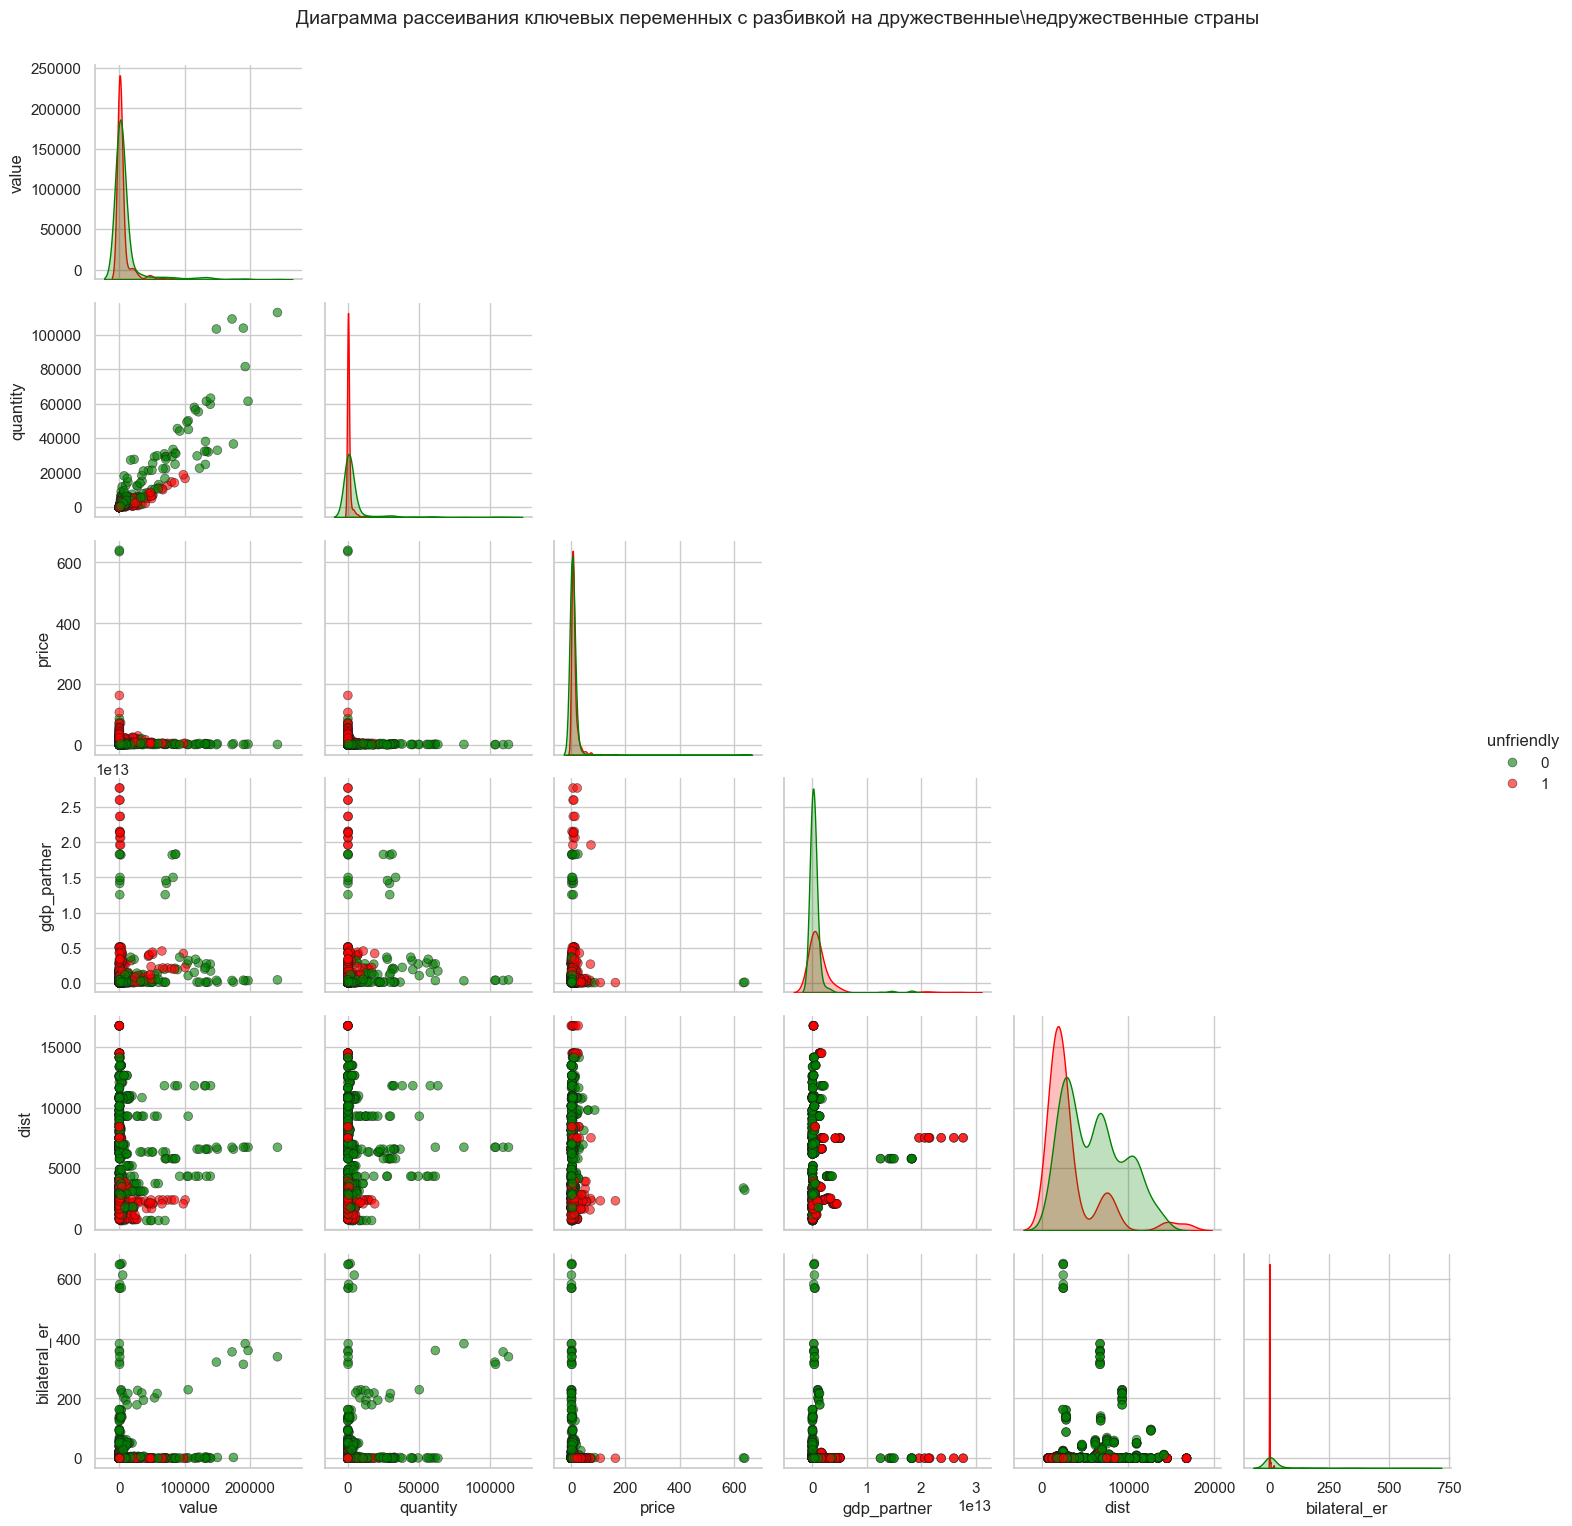

In [10]:
plot_cols = ["value", "quantity", "price", "gdp_partner", "dist", "bilateral_er"]

df_plot = clean_data[plot_cols + ['unfriendly']].dropna()
palette = {0: "green", 1: "red"}

sns.set(style="whitegrid", font_scale=1.0)
pairplot = sns.pairplot(
    df_plot,
    vars=plot_cols,
    hue="unfriendly",
    palette=palette,
    diag_kind="kde",
    plot_kws={"alpha":0.6, "s":40, "edgecolor":"k"}
)

pairplot.fig.suptitle("Диаграмма рассеивания ключевых переменных с разбивкой на дружественные\недружественные страны", y=1.02, fontsize=14)

for i, j in zip(*np.triu_indices_from(pairplot.axes, 1)):
    pairplot.axes[i, j].set_visible(False)

plt.show()

In [11]:
#среднестатистический партнёр
median_partner = clean_data.groupby("partner")[num_cols].median().mean()
median_partner

value           5.359239e+03
quantity        1.846605e+03
price           8.202940e+00
gdp_partner     6.498661e+11
gdp_russia      1.696441e+12
cpi_partner     6.046378e+00
cpi_russia      4.423381e+00
bilateral_er    1.613338e+01
iip_partner     1.134606e+02
iip_russia      1.164402e+02
dist            5.581451e+03
dtype: float64

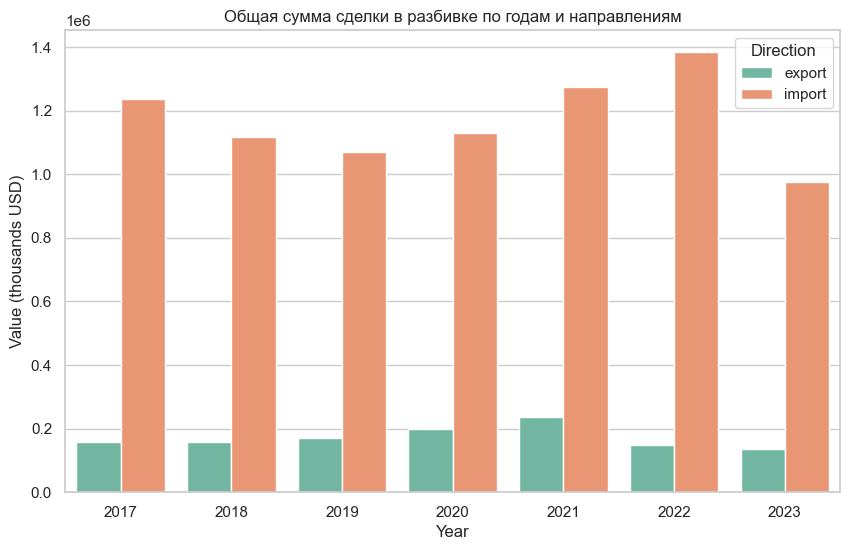

In [12]:
# суммарная стоимость по годам и направлению
yearly_trade = clean_data.groupby(["year", "direction"])["value"].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x="year", y="value", hue="direction", data=yearly_trade, palette="Set2")
plt.title("Общая сумма сделки в разбивке по годам и направлениям")
plt.ylabel("Value (thousands USD)")
plt.xlabel("Year")
plt.legend(title="Direction")
plt.show()

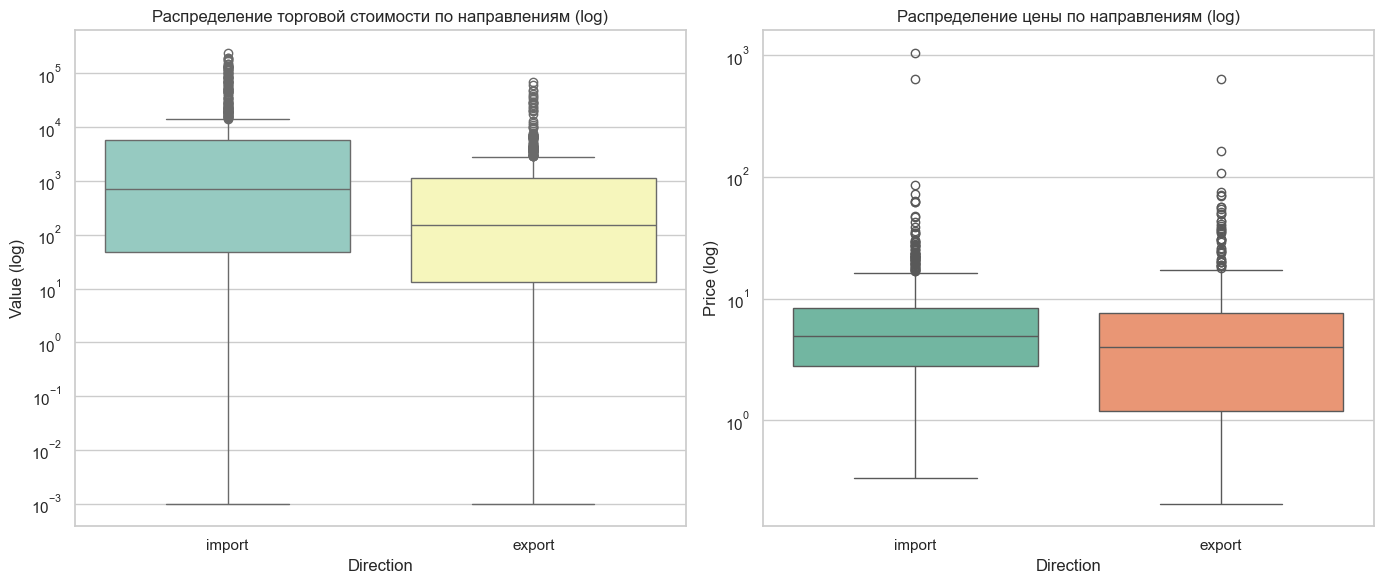

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Боксплот по стоимости
sns.boxplot(x="direction", y="value", data=clean_data, palette="Set3", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Распределение торговой стоимости по направлениям (log)")
axes[0].set_ylabel("Value (log)")
axes[0].set_xlabel("Direction")

# Боксплот по цене
sns.boxplot(x="direction", y="price", data=clean_data, palette="Set2", ax=axes[1])
axes[1].set_yscale("log")  # если хочешь лог
axes[1].set_title("Распределение цены по направлениям (log)")
axes[1].set_ylabel("Price (log)")
axes[1].set_xlabel("Direction")

plt.tight_layout()
plt.show()

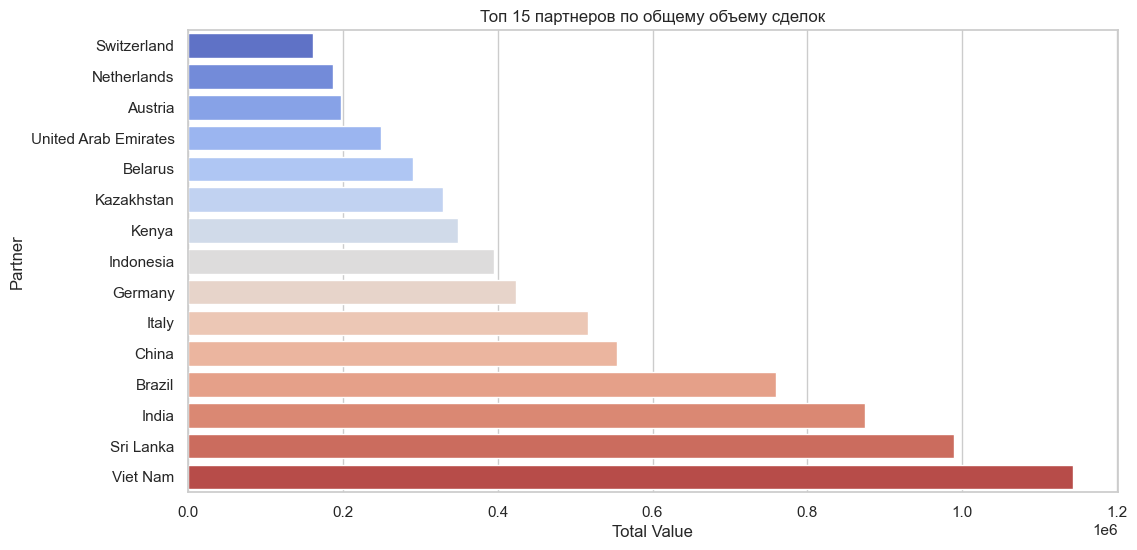

In [14]:
# Распределение торгового объёма по странам-партнёрам

partner_sum = clean_data.groupby("partner")["value"].sum().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(
    x="value", 
    y="partner", 
    data=partner_sum, 
    palette="coolwarm",
    order=partner_sum.sort_values("value", ascending=True)["partner"]
)
plt.title("Топ 15 партнеров по общему объему сделок")
plt.xlabel("Total Value")
plt.ylabel("Partner")
plt.show()

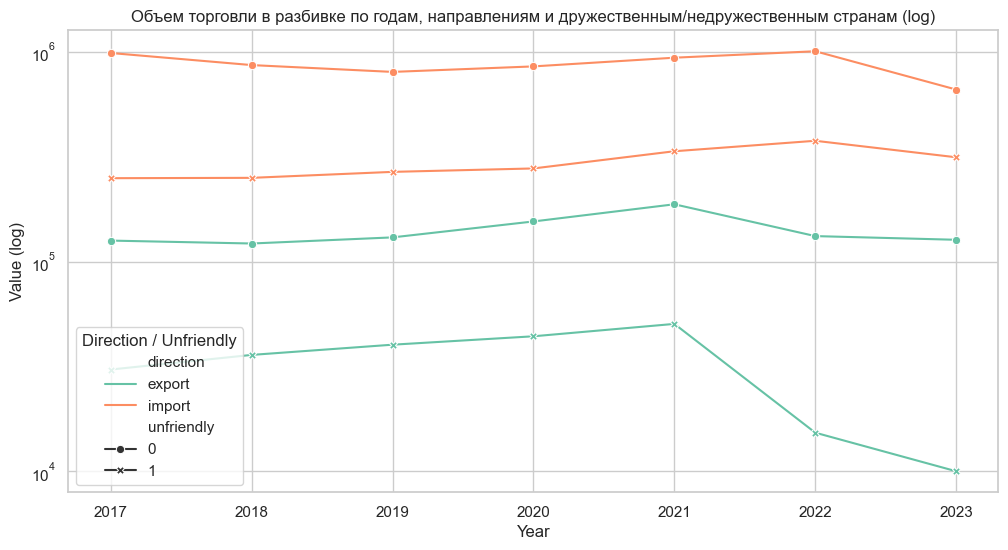

In [15]:
# Динамика по дружественным/недружественным странам
# суммарная стоимость по году, направлению и группе
trade_unfriendly = clean_data.groupby(["year", "unfriendly", "direction"])["value"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(
    data=trade_unfriendly,
    x="year",
    y="value",
    hue="direction",
    style="unfriendly",
    markers=True,
    dashes=False,
    palette="Set2"
)
plt.yscale("log")
plt.title("Объем торговли в разбивке по годам, направлениям и дружественным/недружественным странам (log)")
plt.ylabel("Value (log)")
plt.xlabel("Year")
plt.legend(title="Direction / Unfriendly")
plt.show()

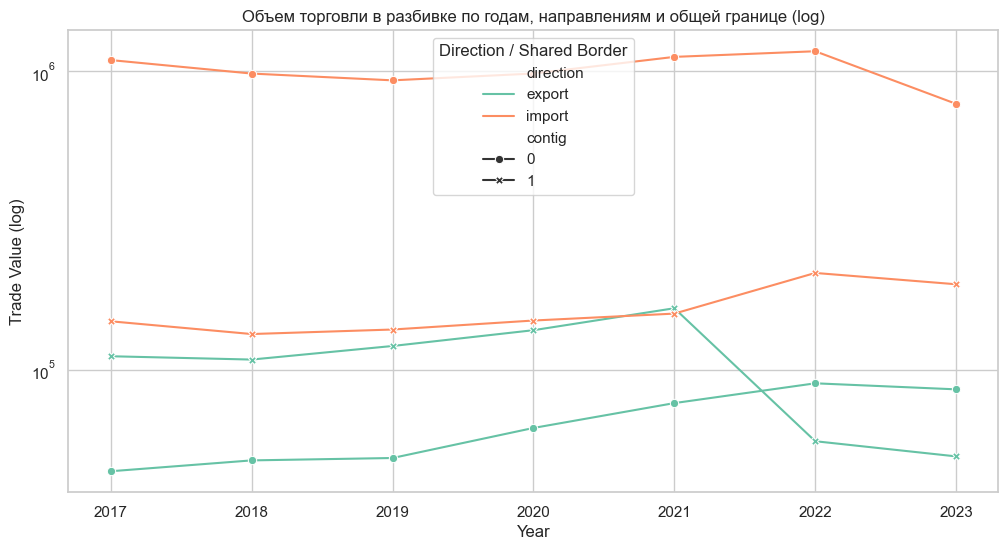

In [16]:
# Динамика по общим границам

trade_contig = clean_data.groupby(["year", "contig", "direction"])["value"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(
    data=trade_contig,
    x="year",
    y="value",
    hue="direction",
    style="contig",
    markers=True,
    dashes=False,
    palette="Set2"
)
plt.yscale("log")
plt.title("Объем торговли в разбивке по годам, направлениям и общей границе (log)")
plt.ylabel("Trade Value (log)")
plt.xlabel("Year")
plt.legend(title="Direction / Shared Border")
plt.show()

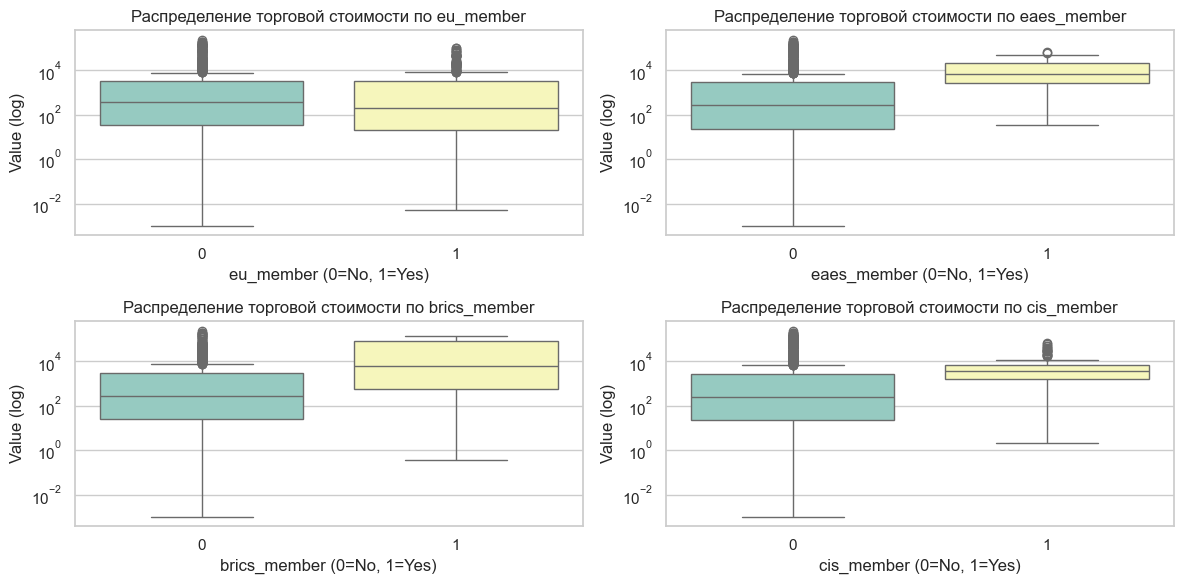

In [17]:
# Boxplot для распределения торговых потоков

union_cols = ["eu_member", "eaes_member", "brics_member", "cis_member"]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(union_cols):
    sns.boxplot(x=col, y="value", data=clean_data, palette="Set3", ax=axes[i])
    axes[i].set_yscale("log")
    axes[i].set_title(f"Распределение торговой стоимости по {col}")
    axes[i].set_ylabel("Value (log)")
    axes[i].set_xlabel(f"{col} (0=No, 1=Yes)")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

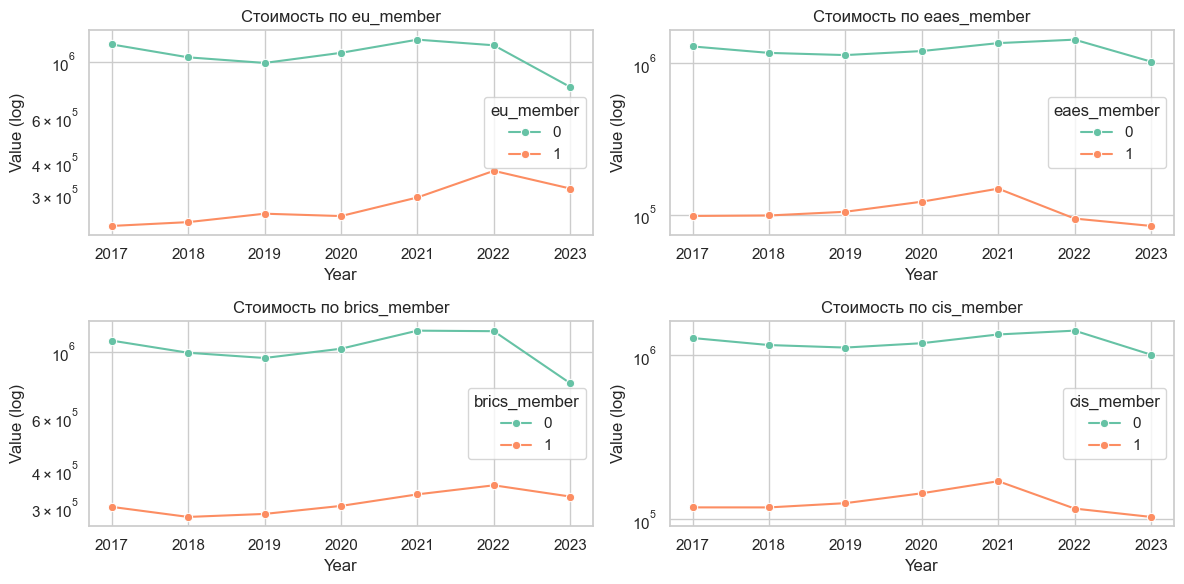

In [18]:
# Динамика торговли по союзам (по годам)
# Видно, как менялся экспорт/импорт с союзными и несоюзными странами по годам.
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()
for i, col in enumerate(union_cols):
    trade_union = clean_data.groupby(["year", col])["value"].sum().reset_index()
    sns.lineplot(
        data=trade_union,
        x="year",
        y="value",
        hue=col,
        marker="o",
        palette="Set2",
        ax=axes[i]
    )
    axes[i].set_yscale("log")
    axes[i].set_title(f"Стоимость по {col}")
    axes[i].set_ylabel("Value (log)")
    axes[i].set_xlabel("Year")
    axes[i].legend(title=col)

plt.tight_layout()
plt.show()

In [19]:
# логарифмируем переменные
data_model = clean_data.copy()
ln_cols = ["value", "quantity", "price", "gdp_partner", "gdp_russia",
           "iip_partner", "iip_russia", "dist", "bilateral_er"]
for col in ln_cols:
    data_model[f"ln_{col}"] = np.log(data_model[col] + 1)

data_model.to_csv("data/result/data_model.csv")
data_model.head(5)

,year,hs2,exporter,importer,exporter_iso3,importer_iso3,partner,partner_iso3,direction,value,...,cis_member,ln_value,ln_quantity,ln_price,ln_gdp_partner,ln_gdp_russia,ln_iip_partner,ln_iip_russia,ln_dist,ln_bilateral_er
0,2017,9,Albania,Russian Federation,ALB,RUS,Albania,ALB,import,10.014,...,0,2.399167,1.791926,1.099412,23.307887,28.084768,4.623207,4.681019,7.632730,1.112312
1,2017,9,Azerbaijan,Russian Federation,AZE,RUS,Azerbaijan,AZE,import,5144.972,...,1,8.545970,6.945864,1.784628,24.433580,28.084768,4.605870,4.681019,7.566180,0.029074
2,2017,9,Argentina,Russian Federation,ARG,RUS,Argentina,ARG,import,2431.309,...,0,7.796596,7.381612,0.922140,27.190387,28.084768,4.592996,4.681019,9.510916,0.249891
3,2017,9,Australia,Russian Federation,AUS,RUS,Australia,AUS,import,5.605,...,0,1.887827,0.212689,3.204768,27.912873,28.084768,4.603769,4.681019,9.582185,0.022117
4,2017,9,Austria,Russian Federation,AUT,RUS,Austria,AUT,import,19119.567,...,0,9.858520,6.712837,3.188936,26.751366,28.084768,4.686381,4.681019,7.424582,0.015059


In [20]:
# Разделяем выборку по направлениям
df_export = data_model[data_model["direction"].eq("export")].copy()
df_import = data_model[data_model["direction"].eq("import")].copy()

compare_vars = [
    "value", "ln_value", "quantity", "ln_quantity", "price", "ln_price",
    "gdp_partner", "ln_gdp_partner", "iip_partner", "ln_iip_partner",
    "dist", "ln_dist", "bilateral_er", "ln_bilateral_er"
]

In [21]:
print("\nexport: описательная статистика по ключевым переменным")
display(describe_vars(df_export, [c for c in compare_vars if "ln_" not in c]))  

print("\nexport: сравнение дружественных/недружественных")
res_export_unf = group_compare_ttest(df_export, "unfriendly", compare_vars)
display(res_export_unf)

print("\nexport: сравнение по общей границе")
res_export_contig = group_compare_ttest(df_export, "contig", compare_vars, group0=0, group1=1)

display(res_export_contig)
print("\nimport: описательная статистика по ключевым переменным")
display(describe_vars(df_import, [c for c in compare_vars if "ln_" not in c]))

print("\nimport: сравнение дружественных/недружественных")
res_import_unf = group_compare_ttest(df_import, "unfriendly", compare_vars)
display(res_import_unf)

print("\nimport: сравнение по общей границе")
res_import_contig = group_compare_ttest(df_import, "contig", compare_vars, group0=0, group1=1)
display(res_import_contig)


export: описательная статистика по ключевым переменным


,count,mean,std,min,25%,50%,75%,max
value,574.0,2.103552e+03,6.675893e+03,1.000000e-03,1.346775e+01,1.534865e+02,1.157429e+03,6.977482e+04
quantity,574.0,9.226995e+02,2.690727e+03,1.000000e-03,2.160000e+00,7.355700e+01,5.393753e+02,2.778519e+04
price,574.0,8.173224e+00,2.917469e+01,2.066832e-01,1.204581e+00,4.000000e+00,7.634099e+00,6.401875e+02
gdp_partner,569.0,9.989724e+11,3.136732e+12,3.176126e+09,4.269300e+10,2.073056e+11,5.313065e+11,2.772071e+13
iip_partner,538.0,1.153100e+02,1.945254e+01,6.458000e+01,1.032675e+02,1.107600e+02,1.222475e+02,2.010100e+02
dist,554.0,4.323768e+03,3.372283e+03,6.869657e+02,1.927484e+03,2.985871e+03,6.576936e+03,1.677449e+04
bilateral_er,566.0,1.292433e+01,5.799923e+01,3.607070e-03,1.386617e-02,6.412599e-02,1.216278e+00,6.487723e+02



export: сравнение дружественных/недружественных


,mean0,mean1,diff,se0,se1,t_stat,p_value,n0,n1
var,,,,,,,,,
value,3.123913e+03,8.712699e+02,2.252643e+03,4.758745e+02,1.949342e+02,4.380420,1.503684e-05,314,260
ln_value,5.467906e+00,4.131679e+00,1.336227e+00,1.626520e-01,1.583627e-01,5.886155,6.754709e-09,314,260
quantity,1.432614e+03,3.068802e+02,1.125733e+03,1.960061e+02,5.345849e+01,5.540967,5.831070e-08,314,260
ln_quantity,4.811758e+00,3.070085e+00,1.741673e+00,1.610394e-01,1.557107e-01,7.775052,3.546502e-14,314,260
price,6.534442e+00,1.015237e+01,-3.617924e+00,2.050926e+00,1.037257e+00,-1.574172,1.161391e-01,314,260
ln_price,1.369346e+00,1.902920e+00,-5.335739e-01,4.801414e-02,5.719834e-02,-7.144863,2.972743e-12,314,260
gdp_partner,6.365062e+11,1.429750e+12,-7.932435e+11,1.365348e+11,2.352126e+11,-2.916677,3.726353e-03,309,260
ln_gdp_partner,2.535268e+01,2.653286e+01,-1.180178e+00,9.901806e-02,1.086697e-01,-8.027554,6.071908e-15,309,260
iip_partner,1.179455e+02,1.123631e+02,5.582379e+00,1.308853e+00,9.769851e-01,3.417899,6.815974e-04,284,254



export: сравнение по общей границе


...

,count,mean,std,min,25%,50%,75%,max
value,686.0,1.193407e+04,3.045374e+04,1.000000e-03,4.779050e+01,7.059725e+02,5.708472e+03,2.417612e+05
quantity,686.0,3.842944e+03,1.238083e+04,1.000000e-03,7.917000e+00,1.629710e+02,1.606326e+03,1.128912e+05
price,686.0,9.948225e+00,4.723201e+01,3.333333e-01,2.795185e+00,4.896526e+00,8.381473e+00,1.050000e+03
gdp_partner,682.0,8.641567e+11,2.886354e+12,1.043411e+09,3.537284e+10,1.078856e+11,4.856605e+11,2.772071e+13
iip_partner,620.0,1.152273e+02,1.921700e+01,7.264000e+01,1.034425e+02,1.110200e+02,1.218975e+02,2.097000e+02
dist,672.0,5.497569e+03,3.775848e+03,6.869657e+02,2.214132e+03,4.525518e+03,7.975700e+03,1.677449e+04
bilateral_er,680.0,1.853295e+01,7.075939e+01,3.607070e-03,1.975526e-02,2.045889e-01,4.848683e+00,6.520751e+02



import: сравнение дружественных/недружественных


,mean0,mean1,diff,se0,se1,t_stat,p_value,n0,n1
var,,,,,,,,,
value,1.361493e+04,8.749641e+03,4.865293e+03,1.668620e+03,1.131045e+03,2.413548,1.606089e-02,449,237
ln_value,6.309081e+00,6.352149e+00,-4.306709e-02,1.479120e-01,2.052058e-01,-0.170254,8.648822e-01,449,237
quantity,5.219824e+03,1.234425e+03,3.985399e+03,7.072187e+02,1.856862e+02,5.450572,7.848541e-08,449,237
ln_quantity,5.107337e+00,4.481661e+00,6.256757e-01,1.519874e-01,1.841286e-01,2.620587,9.026875e-03,449,237
price,9.709191e+00,1.040108e+01,-6.918869e-01,2.740752e+00,5.524270e-01,-0.247467,8.046516e-01,449,237
ln_price,1.675006e+00,2.243769e+00,-5.687629e-01,3.493129e-02,3.834656e-02,-10.964842,1.494226e-25,449,237
gdp_partner,4.985183e+11,1.550693e+12,-1.052175e+12,9.597564e+10,2.565827e+11,-3.840821,1.493024e-04,445,237
ln_gdp_partner,2.509394e+01,2.674578e+01,-1.651847e+00,8.300690e-02,1.041835e-01,-12.400515,4.100389e-31,445,237
iip_partner,1.166693e+02,1.127990e+02,3.870284e+00,1.077538e+00,9.814392e-01,2.655423,8.130945e-03,389,231



import: сравнение по общей границе


,mean0,mean1,diff,se0,se1,t_stat,p_value,n0,n1
var,,,,,,,,,
value,1.207082e+04,1.284662e+04,-7.757971e+02,1.320934e+03,2.231491e+03,-0.299172,7.652121e-01,585,87
ln_value,6.166031e+00,7.675802e+00,-1.509772e+00,1.294482e-01,3.210768e-01,-4.361113,2.821176e-05,585,87
quantity,3.979857e+03,3.533156e+03,4.467006e+02,5.397246e+02,8.383363e+02,0.448022,6.547153e-01,585,87
ln_quantity,4.754610e+00,6.135083e+00,-1.380473e+00,1.293045e-01,2.983475e-01,-4.245482,4.308454e-05,585,87
price,1.011253e+01,9.317911e+00,7.946196e-01,2.107617e+00,1.162919e+00,0.330106,7.414330e-01,585,87
ln_price,1.853172e+00,1.984622e+00,-1.314505e-01,3.059071e-02,8.394355e-02,-1.471289,1.440661e-01,585,87
gdp_partner,7.948712e+11,1.446814e+12,-6.519425e+11,1.089563e+11,4.707877e+11,-1.349131,1.805251e-01,582,86
ln_gdp_partner,2.568035e+01,2.560180e+01,7.855163e-02,7.870120e-02,1.981747e-01,0.368389,7.132694e-01,582,86
iip_partner,1.139611e+02,1.228159e+02,-8.854745e+00,8.484597e-01,1.965282e+00,-4.136549,6.561374e-05,519,87


#### Описательная статистика ключевых переменных

**Импорт**:

* `value` и `quantity` сильно разнятся, среднее > медианы → есть крупные импорты.
* `price` имеет широкий диапазон, редкие дорогие товары.
* `gdp_partner` и `iip_partner` → очень разная экономическая мощность стран.
* `dist` показывает, что большинство поставщиков расположены далеко, но есть соседи.

**Экспорт**:

* `value` и `quantity` также правосторонне распределены, но средние часто чуть выше, чем у импорта → Россия экспортирует крупные потоки в отдельные страны.
* `price` может быть ниже/выше, чем для импорта, в зависимости от отраслей.
* `dist` → Россия экспортирует и в дальние страны, и в соседние.



#### Сравнение дружественных и недружественных стран

**Импорт:**

* Дружественные страны: большее количество и крупнее по объему импорта `quantity`, но `value` не всегда статистически значимо.
* Недружественные страны: `gdp_partner` выше, `dist` меньше, `bilateral_er` ниже → торговля меньше по количеству, но иногда дороже по цене.
* t-тесты: значимые различия по `quantity`, `ex_rate_partner`, `dist`, `bilateral_er`.

**Экспорт:**

* Дружественные страны: Россия экспортирует больше по `value` и `quantity`.
* Недружественные страны: меньше потоков, но отдельные крупные сделки могут влиять на средние.
* t-тесты: часто значимые различия по `value`, `quantity`, `dist`, `bilateral_er` → геополитический фактор отражается сильнее на экспорте.

**Вывод:**

* **Импорт**: различия заметны, но менее выражены по стоимости.
* **Экспорт**: различия сильнее, дружественные страны получают больше экспорта, статистически значимо.

#### Сравнение по общей границе

**Импорт:**

* Соседи → меньше `dist`, больше импорта (`value` и `quantity`).
* `gdp_partner` и `iip_partner` различаются слабее → соседство сильнее влияет на объемы торговли, чем на экономический масштаб.

**Экспорт:**

* Соседи → значительно больше `value` и `quantity`, меньше `dist`.
* t-тест показывает значимость различий → общая граница сильный фактор для экспорта.

**Вывод:**

* Соседство усиливает и экспорт, и импорт, но особенно заметно для экспорта.
* Дружественные и соседние страны могут частично пересекаться, но это разные механизмы влияния на торговлю.